Generate Plot for amplitude 0.5-1.0

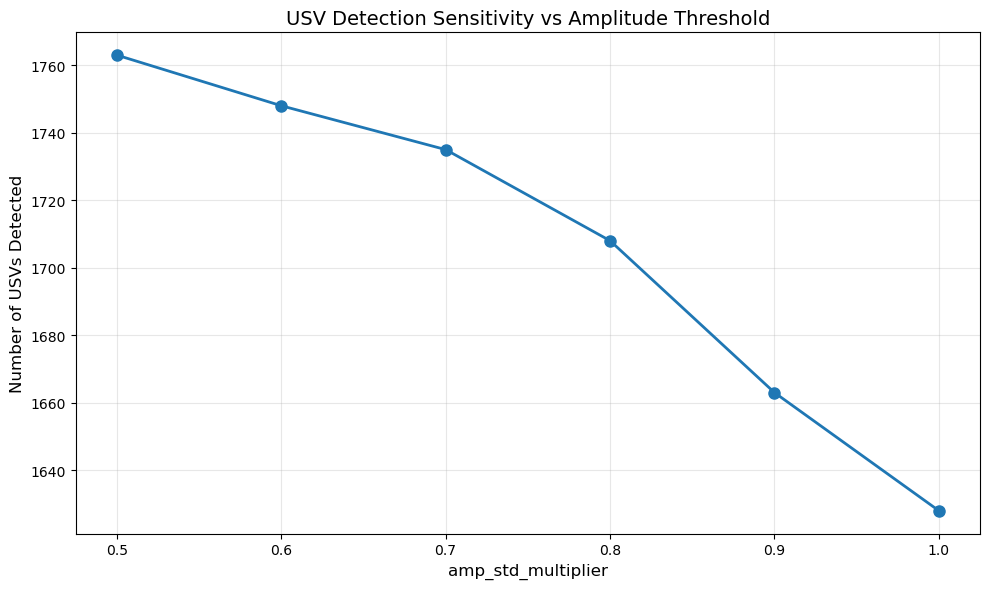

Tested 6 parameters
Range: 1628 to 1763 USVs


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Parameter values tested
amp_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# USV counts from each detection run 
usv_counts = [
    1763,   # amp=0.5 
    1748,   # amp=0.6 
    1735,   # amp=0.7 
    1708,   # amp=0.8 
    1663,   # amp=0.9 
    1628,   # amp=1.0 
]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(amp_values, usv_counts, marker='o', linewidth=2, markersize=8)
plt.xlabel('amp_std_multiplier', fontsize=12)
plt.ylabel('Number of USVs Detected', fontsize=12)
plt.title('USV Detection Sensitivity vs Amplitude Threshold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('parameter_optimization.png', dpi=300)
plt.show()

print(f"Tested {len(amp_values)} parameters")
print(f"Range: {min(usv_counts)} to {max(usv_counts)} USVs")

Comparing Accuracy in the 0.5-1.0 range

Workflow Summary:

- Update Cell 3 with parameter info →
Run Cell 1-3 → Sets everything up
Run Cell 4 → Generates validation lists (CSV files)
Do validation in Audacity → Check the 50 USVs
Update Cell 3 → Fill in validated_real and validated_false numbers
Run Cell 5-6 → Generate the comparison plots

The path changes happen in Cell 3, in the lines that say 'csv_file': r'...'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [3]:
def generate_validation_samples(csv_file, n_samples=50, seed=42):
    """
    Generate random USV indices to validate
    """
    df = pd.read_csv(csv_file)
    total_usvs = len(df)
    
    np.random.seed(seed)
    sample_indices = np.random.choice(total_usvs, size=min(n_samples, total_usvs), replace=False)
    sample_indices = np.sort(sample_indices)
    
    samples = df.iloc[sample_indices][['label', 'start', 'stop']].copy()
    samples['index'] = sample_indices
    samples['validated'] = ''
    
    return samples, total_usvs

In [6]:
parameters = {
    'amp_0.5': {
        'csv_file': r'C:\Users\User\usv_detection\amplitude_test\.5\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO_USV.csv',
        'total_detected': 1763,
        'validated_real': 0,
        'validated_false': 0,
        'color': '#9b59b6'
    },
    'amp_0.6': {
        'csv_file': r'C:\Users\User\usv_detection\amplitude_test\.6\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO_USV.csv',
        'total_detected': 1748,
        'validated_real': 0,
        'validated_false': 0,
        'color': '#2ecc71'
    },
    'amp_0.7': {
        'csv_file': r'C:\Users\User\usv_detection\amplitude_test\.7\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO_USV.csv',
        'total_detected': 1735,
        'validated_real': 0,
        'validated_false': 0,
        'color': '#3498db'
    },
    'amp_0.8': {
        'csv_file': r'C:\Users\User\usv_detection\amplitude_test\.8\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO_USV.csv',
        'total_detected': 1708,
        'validated_real': 0,
        'validated_false': 0,
        'color': '#f39c12'
    },
    'amp_0.9': {
        'csv_file': r'C:\Users\User\usv_detection\amplitude_test\.9\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO_USV.csv',
        'total_detected': 1663,
        'validated_real': 0,
        'validated_false': 0,
        'color': '#e74c3c'
    },
    'amp_1.0': {
        'csv_file': r'C:\Users\User\usv_detection\amplitude_test\1.0\SK4ASK4BSK2ASK2B_USVBehaviorExperiment_Day5Session1_02032026_YO_USV.csv',
        'total_detected': 1628,
        'validated_real': 0,
        'validated_false': 0,
        'color': '#95a5a6'
    }
}

In [7]:
# ============================================================================
# RUN THIS FIRST - Generates random sample lists for validation
# ============================================================================

print("=" * 70)
print("VALIDATION SAMPLE LISTS")
print("=" * 70)

for param_name, param_data in parameters.items():
    if Path(param_data['csv_file']).exists():
        samples, total = generate_validation_samples(param_data['csv_file'], n_samples=50)
        
        print(f"\n{param_name} - Total USVs: {total}")
        print("-" * 70)
        print("Check these USVs in Audacity (already sorted by time):")
        print(samples[['index', 'label', 'start', 'stop']].to_string(index=False))
        
        # Save to file
        output_file = f'validation_list_{param_name}.csv'
        samples.to_csv(output_file, index=False)
        print(f"\nSaved to: {output_file}")
        print("Open this file and mark each USV as 'Real' or 'False' in the 'validated' column")
    else:
        print(f"\n{param_name}: CSV file not found - check the path!")
        print(f"  Looking for: {param_data['csv_file']}")

VALIDATION SAMPLE LISTS

amp_0.5 - Total USVs: 1763
----------------------------------------------------------------------
Check these USVs in Audacity (already sorted by time):
 index    label     start      stop
    29   USV_30  142.2202  142.2362
    65   USV_66  168.7932  168.8022
    70   USV_71  169.7912  170.0082
   109  USV_110  243.1202  243.1372
   115  USV_116  245.6972  245.7362
   203  USV_204  353.9912  354.0202
   212  USV_213  373.0472  373.0602
   220  USV_221  389.4892  389.4972
   239  USV_240  560.3522  560.4562
   247  USV_248  562.5162  562.6222
   251  USV_252  564.3782  564.4042
   339  USV_340  647.4762  647.5092
   367  USV_368  656.3512  656.3882
   383  USV_384  659.2912  659.3112
   416  USV_417  669.6572  669.8832
   464  USV_465  679.1102  679.1402
   495  USV_496  688.9912  689.0062
   570  USV_571  710.2552  710.3232
   582  USV_583  716.0582  716.1392
   609  USV_610  727.2212  727.2992
   629  USV_630  734.1572  734.1732
   677  USV_678  747.7332  747

In [ ]:
def plot_parameter_comparison(parameters):
    """
    Create comprehensive comparison plots for 6 parameters
    """
    # Extract data
    param_names = list(parameters.keys())
    total_detected = [parameters[p]['total_detected'] for p in param_names]
    validated_real = [parameters[p]['validated_real'] for p in param_names]
    validated_false = [parameters[p]['validated_false'] for p in param_names]
    colors = [parameters[p]['color'] for p in param_names]
    
    # Calculate metrics
    precision = [r/(r+f)*100 if (r+f)>0 else 0 for r, f in zip(validated_real, validated_false)]
    false_positive_rate = [f/(r+f)*100 if (r+f)>0 else 0 for r, f in zip(validated_real, validated_false)]
    
    # Estimate totals
    estimated_real = [total * (prec/100) for total, prec in zip(total_detected, precision)]
    estimated_false = [total - real for total, real in zip(total_detected, estimated_real)]
    
    # Create larger figure for 6 parameters
    fig = plt.figure(figsize=(18, 12))
    
    # -------------------------------------------------------------------------
    # Plot 1: Total Detections Comparison
    # -------------------------------------------------------------------------
    ax1 = plt.subplot(2, 3, 1)
    bars = ax1.bar(range(len(param_names)), total_detected, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax1.set_ylabel('Number of USVs Detected', fontsize=12, fontweight='bold')
    ax1.set_title('Total Detections by Parameter', fontsize=13, fontweight='bold')
    ax1.set_xticks(range(len(param_names)))
    ax1.set_xticklabels(param_names, rotation=45, ha='right')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, total_detected)):
        height = bar.get_height()
        ax1.text(i, height, f'{int(val)}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
  
    # Plot 2: Precision Comparison
 
    ax2 = plt.subplot(2, 3, 2)
    bars = ax2.bar(range(len(param_names)), precision, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax2.set_ylabel('Precision (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Detection Precision\n(True Positives / All Detections)', fontsize=13, fontweight='bold')
    ax2.set_xticks(range(len(param_names)))
    ax2.set_xticklabels(param_names, rotation=45, ha='right')
    ax2.set_ylim(0, 105)
    ax2.axhline(y=90, color='green', linestyle='--', linewidth=2, alpha=0.5, label='90% target')
    ax2.axhline(y=85, color='orange', linestyle=':', linewidth=2, alpha=0.5, label='85% minimum')
    ax2.grid(axis='y', alpha=0.3)
    ax2.legend(fontsize=9)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, precision)):
        height = bar.get_height()
        ax2.text(i, height, f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
  
    # Plot 3: Combined Curve (Detections + Precision)
    
    ax3 = plt.subplot(2, 3, 3)
    amp_values = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    
    # Plot detections on left y-axis
    ax3_left = ax3
    line1 = ax3_left.plot(amp_values, total_detected, 'b-o', linewidth=2.5, markersize=8, label='Total Detected')
    ax3_left.set_xlabel('amp_std_multiplier', fontsize=12, fontweight='bold')
    ax3_left.set_ylabel('USVs Detected', color='b', fontsize=12, fontweight='bold')
    ax3_left.tick_params(axis='y', labelcolor='b')
    ax3_left.grid(True, alpha=0.3)
    
    # Plot precision on right y-axis
    ax3_right = ax3_left.twinx()
    line2 = ax3_right.plot(amp_values, precision, 'r-s', linewidth=2.5, markersize=8, label='Precision %')
    ax3_right.set_ylabel('Precision (%)', color='r', fontsize=12, fontweight='bold')
    ax3_right.tick_params(axis='y', labelcolor='r')
    ax3_right.set_ylim(0, 105)
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax3_left.legend(lines, labels, loc='upper left', fontsize=9)
    ax3_left.set_title('Quantity vs Quality Trade-off', fontsize=13, fontweight='bold')
    

    # Plot 4: Validated Sample Breakdown (Stacked)

    ax4 = plt.subplot(2, 3, 4)
    x = np.arange(len(param_names))
    
    bars1 = ax4.bar(x, validated_real, label='Real USVs', 
                    color='#27ae60', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax4.bar(x, validated_false, bottom=validated_real, label='False Positives',
                    color='#c0392b', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax4.set_ylabel('Count (out of 50 validated)', fontsize=12, fontweight='bold')
    ax4.set_title('Validation Sample Breakdown', fontsize=13, fontweight='bold')
    ax4.set_xticks(x)
    ax4.set_xticklabels(param_names, rotation=45, ha='right')
    ax4.legend(fontsize=10)
    ax4.grid(axis='y', alpha=0.3)
    ax4.set_ylim(0, 55)
    
    # Add value labels
    for i, (real, false) in enumerate(zip(validated_real, validated_false)):
        # Real count
        if real > 0:
            ax4.text(i, real/2, f'{int(real)}', ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=9)
        # False count
        if false > 0:
            ax4.text(i, real + false/2, f'{int(false)}', ha='center', va='center',
                    color='white', fontweight='bold', fontsize=9)
        # Total on top
        ax4.text(i, real + false + 1, '50', ha='center', va='bottom', fontsize=8, style='italic')
    
 
    # Plot 5: Estimated Real USVs in Full Dataset

    ax5 = plt.subplot(2, 3, 5)
    x = np.arange(len(param_names))
    
    bars1 = ax5.bar(x, estimated_real, label='Estimated Real USVs',
                    color='#27ae60', alpha=0.8, edgecolor='black', linewidth=1.5)
    bars2 = ax5.bar(x, estimated_false, bottom=estimated_real,
                    label='Estimated False Positives', color='#c0392b', alpha=0.8, edgecolor='black', linewidth=1.5)
    
    ax5.set_ylabel('Estimated Count (Full Dataset)', fontsize=12, fontweight='bold')
    ax5.set_title('Projected Quality in Full Dataset\n(Based on Validation)', fontsize=13, fontweight='bold')
    ax5.set_xticks(x)
    ax5.set_xticklabels(param_names, rotation=45, ha='right')
    ax5.legend(fontsize=10)
    ax5.grid(axis='y', alpha=0.3)
    
    # Add labels
    for i, (real, false) in enumerate(zip(estimated_real, estimated_false)):
        total = real + false
        # Real count inside bar
        ax5.text(i, real/2, f'{int(real)}', ha='center', va='center', 
                color='white', fontweight='bold', fontsize=9)
        # Total on top
        ax5.text(i, total + 20, f'{int(total)}', ha='center', va='bottom', 
                fontweight='bold', fontsize=9)
    
    
    # Plot 6: Summary Metrics Table
   
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('tight')
    ax6.axis('off')
    
    table_data = []
    for i, param in enumerate(param_names):
        row = [
            param,
            f"{total_detected[i]:,}",
            f"{precision[i]:.1f}%",
            f"{false_positive_rate[i]:.1f}%",
            f"{int(estimated_real[i]):,}"
        ]
        table_data.append(row)
    
    table = ax6.table(cellText=table_data,
                     colLabels=['Parameter', 'Total\nDetected', 'Precision', 'FP Rate', 'Est. Real\nUSVs'],
                     cellLoc='center',
                     loc='center',
                     colColours=['lightgray']*5)
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2.2)
    
    # Color code the parameter column
    for i in range(1, len(param_names) + 1):
        table[(i, 0)].set_facecolor(colors[i-1])
        table[(i, 0)].set_alpha(0.4)
    
    # Highlight best precision
    best_precision_idx = np.argmax(precision)
    table[(best_precision_idx + 1, 2)].set_facecolor('#2ecc71')
    table[(best_precision_idx + 1, 2)].set_alpha(0.3)
    
    # Highlight most real USVs
    most_real_idx = np.argmax(estimated_real)
    table[(most_real_idx + 1, 4)].set_facecolor('#3498db')
    table[(most_real_idx + 1, 4)].set_alpha(0.3)
    
    ax6.set_title('Summary Statistics', fontsize=13, fontweight='bold', pad=20)
    

    # Title and layout
    
    plt.suptitle('Parameter Optimization Comparison - USV Detection (6 Parameters)', 
                 fontsize=17, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    
    # Save figure
    plt.savefig('parameter_comparison_6params.png', dpi=300, bbox_inches='tight')
    print("\n✓ Plot saved as: parameter_comparison_6params.png")
    
    plt.show()
    
 
    # Print Summary to Console
  
    print("\n" + "=" * 80)
    print("VALIDATION SUMMARY - ALL 6 PARAMETERS")
    print("=" * 80)
    for i, param in enumerate(param_names):
        print(f"\n{param}:")
        print(f"  Total Detected:        {total_detected[i]:,}")
        print(f"  Validated (50 sample): {validated_real[i]} real, {validated_false[i]} false")
        print(f"  Precision:             {precision[i]:.1f}%")
        print(f"  False Positive Rate:   {false_positive_rate[i]:.1f}%")
        print(f"  Estimated Real USVs:   {int(estimated_real[i]):,} (in full dataset)")
    
    # Recommendation
    print("\n" + "=" * 80)
    print("ANALYSIS & RECOMMENDATION")
    print("=" * 80)
    
    best_precision_idx = np.argmax(precision)
    most_real_idx = np.argmax(estimated_real)
    
    print(f"\n Highest Precision: {param_names[best_precision_idx]} ({precision[best_precision_idx]:.1f}%)")
    print(f" Most Real USVs:    {param_names[most_real_idx]} ({int(estimated_real[most_real_idx]):,} estimated)")
    
    # Find parameters with >85% precision
    good_params = [(i, param_names[i], precision[i], estimated_real[i]) 
                   for i in range(len(param_names)) if precision[i] >= 85]
    
    if good_params:
        print(f"\n✓ Parameters with ≥85% precision:")
        for idx, name, prec, real in good_params:
            print(f"  - {name}: {prec:.1f}% precision, ~{int(real):,} real USVs")
        
        # Recommend the one with most real USVs among good ones
        best_among_good = max(good_params, key=lambda x: x[3])
        print(f"\n RECOMMENDED: {best_among_good[1]}")
        print(f"   Balances high precision ({best_among_good[2]:.1f}%) with maximum USV capture (~{int(best_among_good[3]):,})")
    else:
        print("\n No parameters achieved ≥85% precision - consider adjusting thresholds")
    
    # Trade-off analysis
    print(f"\n Trade-off Analysis:")
    print(f"   Lower thresholds (0.5-0.6): More USVs but potentially more noise")
    print(f"   Higher thresholds (0.9-1.0): Cleaner but may miss weak real calls")

In [ ]:
# RUN THIS AFTER you've updated the validation numbers in Cell 3

plot_parameter_comparison(parameters)